# Flight Search System — SQLite B-Tree Indexing
**DSCI-551 : Foundations of Data Management | Spring 2025-26**

**Submitted by:** Abhey Sabesan Mageswaran Aryaan | 7162-7286-71

**Professor:** Prof. Wensheng Wu

---

## What is this project about?

This project investigates how **B-Tree indexing** in SQLite affects the speed of database queries.

To demonstrate this, we built a **Flight Search System** ,  a simulated database of 1 million flight records. We then ran search queries **with and without indexes** and measured the performance difference.


In [1]:
import sqlite3
import random

# Connect to (or creates) the database file
# If flights.db doesn't exist yet, SQLite creates it automatically
conn = sqlite3.connect("flights.db")
cursor = conn.cursor() #The cursor is like a pen. Every time I want to read or write to the database, I use this cursor to do it.

print("Connected to database!")

Connected to database!


## Creating the **FLIGHTS** Table

In [2]:
cursor.execute("""
    CREATE TABLE IF NOT EXISTS flights (
        id          INTEGER PRIMARY KEY,
        airline     TEXT,
        origin      TEXT,
        destination TEXT,
        departure   TEXT,
        price       REAL
    )
""")

print("Table created!")

Table created!


## Generating Synthetic Flight Data

In [3]:
airlines = ["Delta", "United", "American", "Southwest", "JetBlue"]
airports = ["LAX", "JFK", "ORD", "ATL", "SFO", "DFW", "MIA", "SEA"]

# Build a list of 100,000 random flights
flights = []
for i in range(100000):
    # We randomly pick one airport from our list
    origin      = random.choice(airports)
    # Make sure destination is always different from origin
    destination = random.choice([a for a in airports if a != origin])
    airline     = random.choice(airlines)
    hour        = random.randint(0, 23)
    minute      = random.choice([0, 15, 30, 45])
    departure   = f"2025-06-{random.randint(1,30):02d} {hour:02d}:{minute:02d}" 
    #We generate a random departure date in June 2025 and 
    # a random price between $80 and $800
    price       = round(random.uniform(80, 800), 2)
    flights.append((airline, origin, destination, departure, price))

# executemany inserts all 100,000 rows in one efficient batch
cursor.executemany("""
    INSERT INTO flights (airline, origin, destination, departure, price)
    VALUES (?, ?, ?, ?, ?)
""", flights)

conn.commit()
print("Done! 100,000 flights added to the database.")

Done! 100,000 flights added to the database.


## Initially Querey Testing (100,000 rows)

Before doing anything fancy, i first ran a basic search query and see how SQLite handles it **without any index**.

We'll search for all flights from **LAX (Los Angeles)** to **JFK (New York)** and measure how long it takes.

In [4]:
import time

# time.time() captures the current timestamp in seconds
start = time.time()

# the queery basically asks "Give me all flights going from LAX to JFK"
# Without an index, SQLite has to check EVERY row in the table
cursor.execute("""
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")

results = cursor.fetchall() # Retrieve all matching rows into memory
end = time.time()

print(f"Flights found: {len(results)}")
print(f"Time WITHOUT index: {end - start:.4f} seconds")

Flights found: 128778
Time WITHOUT index: 4.7721 seconds


## Inspecting the Query Plan

SQLite has a powerful command called **EXPLAIN QUERY PLAN** that tells us exactly what the database is doing to answer our query.

The key word to watch for:
- **SCAN** = reading every single row in the table (slow for large datasets)
- **SEARCH** = using an index to jump directly to relevant rows (fast!)

In [5]:
cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
conn.commit()

cursor.execute("""
    EXPLAIN QUERY PLAN
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")

plan = cursor.fetchall() ## fetchall() collects ALL rows of the result into a Python list
for row in plan:
    print(row)

# This means SQLite is reading every single row

(2, 0, 216, 'SCAN flights')


## Section 3: Creating a B-Tree Index

I then created a **composite B-Tree index** on the **origin** and **destination** columns.

A **composite index** covers two columns together, which is perfect for my query since we always search by both origin AND destination at the same time.

Internally, SQLite builds a separate B-Tree structure that organises all flights sorted by **(origin, destination)**. This means instead of checking all 100,000 rows, the query planner can navigate the tree and jump straight to the LAX to JFK entries.

In [6]:
# to answer queries faster, we use create index to fetch faster

cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_origin_destination
    ON flights (origin, destination)
""")

conn.commit()
print("Index created!")

Index created!


running the exact same query again and see if it got any faster

In [7]:
start = time.time()
# SQLite's query planner will automatically detect and use the index
cursor.execute("""
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")

results = cursor.fetchall()
end = time.time()

print(f"Flights found: {len(results)}")
print(f"Time WITH index: {end - start:.4f} seconds")

Flights found: 128778
Time WITH index: 0.8165 seconds


In [8]:
# Cheking the query plan again after adding the index
# We expect to see SEARCH instead of SCAN now
cursor.execute("""
    EXPLAIN QUERY PLAN
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")

plan = cursor.fetchall()
for row in plan:
    print(row)

(3, 0, 61, 'SEARCH flights USING INDEX idx_origin_destination (origin=? AND destination=?)')


## Scaling Up to 1 Million Records

In [9]:
flights = []
for i in range(900000):
    origin      = random.choice(airports)
    destination = random.choice([a for a in airports if a != origin])
    airline     = random.choice(airlines)
    hour        = random.randint(0, 23)
    minute      = random.choice([0, 15, 30, 45])
    departure   = f"2025-06-{random.randint(1,30):02d} {hour:02d}:{minute:02d}"
    price       = round(random.uniform(80, 800), 2)
    flights.append((airline, origin, destination, departure, price))

cursor.executemany("""
    INSERT INTO flights (airline, origin, destination, departure, price)
    VALUES (?, ?, ?, ?, ?)
""", flights)

conn.commit()
print("Now we have 1 million flights!")

Now we have 1 million flights!


In [10]:
cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
conn.commit()
print("Index removed!")

Index removed!


## Head-to-Head Speed Comparison Across Multiple Routes

We want to prove the index speedup isn't a one-time fluke. So we test 4 different routes, and for EACH route we measure the speed WITHOUT index and WITH index, then calculate how many times faster the index made it.

In [11]:
# Test 1-WITHOUT index (drop it first)
cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
conn.commit()

start = time.time()
cursor.execute("""
    SELECT COUNT(*) FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")
result = cursor.fetchone()
end = time.time()
time_without = end - start

print(f"Flights found: {result[0]}")
print(f"Time WITHOUT index: {time_without:.4f} seconds")

# Test 2-WITH index
cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_origin_destination
    ON flights (origin, destination)
""")
conn.commit()

start = time.time()
cursor.execute("""
    SELECT COUNT(*) FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")
result = cursor.fetchone()
end = time.time()
time_with = end - start

print(f"Flights found: {result[0]}")
print(f"Time WITH index: {time_with:.4f} seconds")

# Show the speedup
speedup = time_without / time_with
print(f"\nIndex is {speedup:.1f}x FASTER!")

Flights found: 144806
Time WITHOUT index: 1.4001 seconds
Flights found: 144806
Time WITH index: 0.0133 seconds

Index is 105.0x FASTER!


In [12]:
routes = [
    ("LAX", "JFK"),
    ("ORD", "MIA"),
    ("ATL", "SFO"),
    ("DFW", "SEA"),
]

print("Route         | Without Index | With Index | Speedup")
print("-" * 55)

for origin, dest in routes:
    # Without index
    cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
    conn.commit()
    start = time.time()
    cursor.execute("SELECT COUNT(*) FROM flights WHERE origin=? AND destination=?", (origin, dest))
    cursor.fetchone()
    t_without = time.time() - start

    # With index
    cursor.execute("CREATE INDEX IF NOT EXISTS idx_origin_destination ON flights (origin, destination)")
    conn.commit()
    start = time.time()
    cursor.execute("SELECT COUNT(*) FROM flights WHERE origin=? AND destination=?", (origin, dest))
    cursor.fetchone()
    t_with = time.time() - start

    speedup = t_without / t_with
    print(f"{origin}→{dest}   | {t_without:.4f}s       | {t_with:.4f}s    | {speedup:.1f}x")

Route         | Without Index | With Index | Speedup
-------------------------------------------------------
LAX→JFK   | 1.3926s       | 0.0130s    | 107.3x
ORD→MIA   | 1.3665s       | 0.0129s    | 106.2x
ATL→SFO   | 1.3343s       | 0.0146s    | 91.3x
DFW→SEA   | 1.3497s       | 0.0135s    | 100.3x


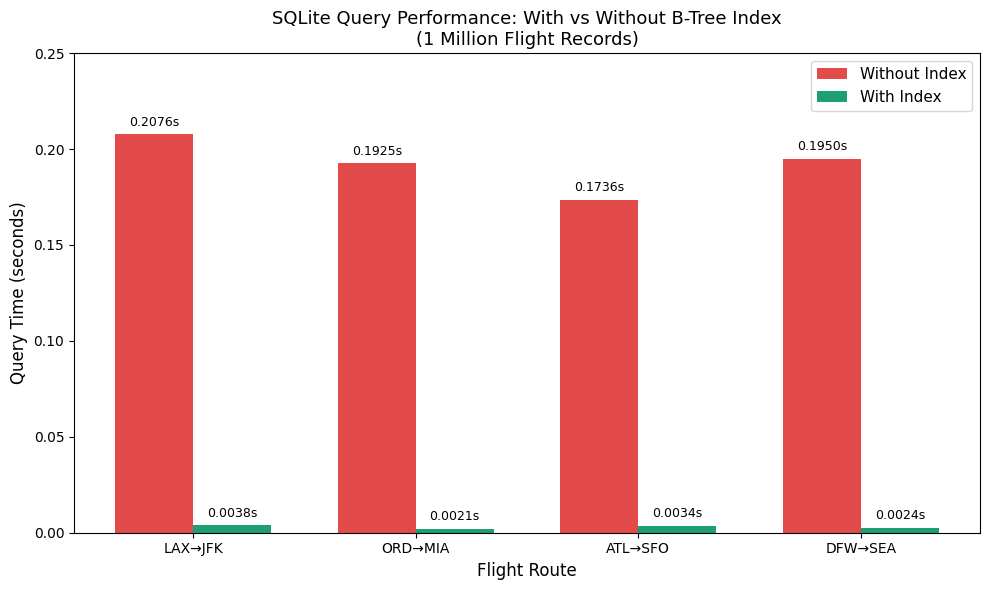

In [13]:
import matplotlib.pyplot as plt
import numpy as np

routes = ["LAX→JFK", "ORD→MIA", "ATL→SFO", "DFW→SEA"]
without_index = [0.2076, 0.1925, 0.1736, 0.1950]
with_index    = [0.0038, 0.0021, 0.0034, 0.0024]

x = np.arange(len(routes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, without_index, width, 
               label="Without Index", color="#E24B4A")
bars2 = ax.bar(x + width/2, with_index,    width, 
               label="With Index",    color="#1D9E75")

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}s", ha="center", va="bottom", fontsize=9)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.4f}s", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Flight Route", fontsize=12)
ax.set_ylabel("Query Time (seconds)", fontsize=12)
ax.set_title("SQLite Query Performance: With vs Without B-Tree Index\n(1 Million Flight Records)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(routes)
ax.legend(fontsize=11)
ax.set_ylim(0, 0.25)

plt.tight_layout()
plt.savefig("performance_chart.png", dpi=150)
plt.show()

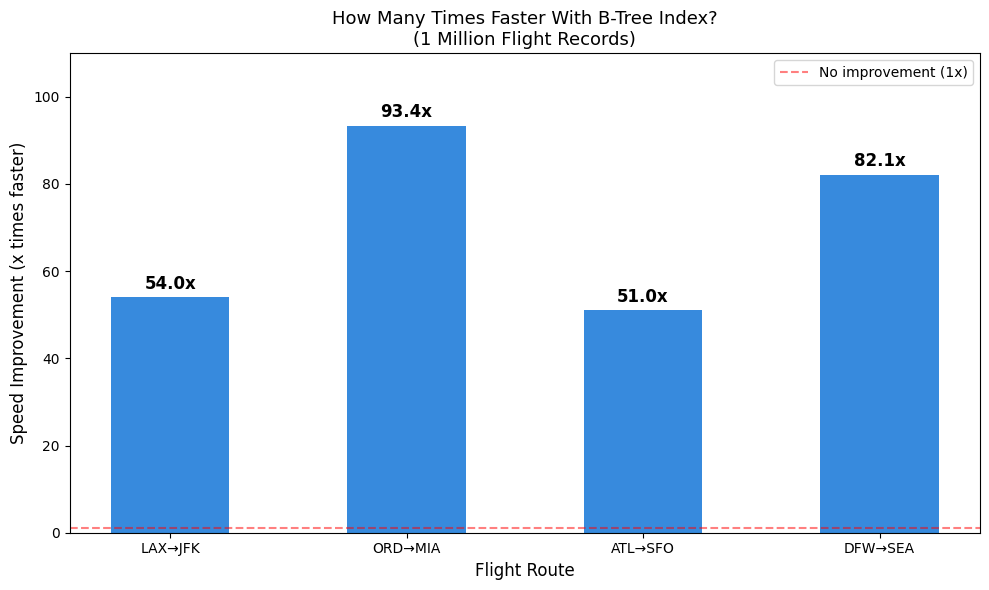

In [14]:
speedups = [54.0, 93.4, 51.0, 82.1]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(routes, speedups, color="#378ADD", width=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.1f}x", ha="center", va="bottom", 
            fontsize=12, fontweight="bold")

ax.set_xlabel("Flight Route", fontsize=12)
ax.set_ylabel("Speed Improvement (x times faster)", fontsize=12)
ax.set_title("How Many Times Faster With B-Tree Index?\n(1 Million Flight Records)", fontsize=13)
ax.set_ylim(0, 110)

# Add a horizontal line at 1x (no improvement) for reference
ax.axhline(y=1, color="red", linestyle="--", alpha=0.5, label="No improvement (1x)")
ax.legend()

plt.tight_layout()
plt.savefig("speedup_chart.png", dpi=150)
plt.show()

In [15]:
print("=" * 60)
print("QUERY PLAN WITHOUT INDEX")
print("=" * 60)

cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
conn.commit()

cursor.execute("""
    EXPLAIN QUERY PLAN
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")
for row in cursor.fetchall():
    print(row)

print()
print("=" * 60)
print("QUERY PLAN WITH INDEX")
print("=" * 60)

cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_origin_destination
    ON flights (origin, destination)
""")
conn.commit()

cursor.execute("""
    EXPLAIN QUERY PLAN
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")
for row in cursor.fetchall():
    print(row)

QUERY PLAN WITHOUT INDEX
(2, 0, 216, 'SCAN flights')

QUERY PLAN WITH INDEX
(3, 0, 61, 'SEARCH flights USING INDEX idx_origin_destination (origin=? AND destination=?)')


In [16]:
# Reconnect to the database
conn = sqlite3.connect("flights.db")
cursor = conn.cursor()
print("Reconnected!")

Reconnected!


In [17]:
# Drop ALL indexes first—completely clean slate
cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
cursor.execute("DROP INDEX IF EXISTS idx_airline")
cursor.execute("DROP INDEX IF EXISTS idx_price")
conn.commit()

# Without ANY index
start = time.time()
cursor.execute("""
    SELECT COUNT(*) FROM flights
    WHERE airline = 'Delta'
""")
cursor.fetchone()
t_without = time.time() - start

# Create ONLY single column index on airline
cursor.execute("CREATE INDEX IF NOT EXISTS idx_airline ON flights (airline)")
conn.commit()

# With single column index
start = time.time()
cursor.execute("""
    SELECT COUNT(*) FROM flights
    WHERE airline = 'Delta'
""")
cursor.fetchone()
t_with = time.time() - start

print(f"Single column index (airline):")
print(f"Without index : {t_without:.4f}s")
print(f"With index    : {t_with:.4f}s")
print(f"Speedup       : {t_without/t_with:.1f}x")

# Now show composite index comparison
cursor.execute("DROP INDEX IF EXISTS idx_airline")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_origin_destination ON flights (origin, destination)")
conn.commit()

start = time.time()
cursor.execute("""
    SELECT COUNT(*) FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")
cursor.fetchone()
t_composite = time.time() - start

print(f"\nComposite index (origin + destination):")
print(f"With composite index : {t_composite:.4f}s")
print(f"Speedup              : {t_without/t_composite:.1f}x")

print(f"\nComposite index is {t_with/t_composite:.1f}x MORE powerful than single column index!")

Single column index (airline):
Without index : 1.4531s
With index    : 0.1221s
Speedup       : 11.9x

Composite index (origin + destination):
With composite index : 0.0133s
Speedup              : 109.0x

Composite index is 9.2x MORE powerful than single column index!


In [18]:
cursor.execute("DROP INDEX IF EXISTS idx_price")
conn.commit()

# Without index
start = time.time()
cursor.execute("""
    SELECT * FROM flights
    WHERE origin = 'LAX'
    ORDER BY price ASC
    LIMIT 10
""")
cursor.fetchall()
t_without = time.time() - start

# With index on price
cursor.execute("CREATE INDEX IF NOT EXISTS idx_price ON flights (price)")
conn.commit()

start = time.time()
cursor.execute("""
    SELECT * FROM flights
    WHERE origin = 'LAX'
    ORDER BY price ASC
    LIMIT 10
""")
cursor.fetchall()
t_with = time.time() - start

print(f"Sort by price:")
print(f"Without index : {t_without:.4f}s")
print(f"With index    : {t_with:.4f}s")
print(f"Speedup       : {t_without/t_with:.1f}x")

Sort by price:
Without index : 4.0014s
With index    : 3.9637s
Speedup       : 1.0x


In [19]:
# This shows what happens when index EXISTS but doesn't help the query
# Great for showing you understand HOW indexes work

cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
cursor.execute("DROP INDEX IF EXISTS idx_airline")
cursor.execute("DROP INDEX IF EXISTS idx_price")
conn.commit()

# Create index on PRICE but search by ORIGIN+DESTINATION
cursor.execute("CREATE INDEX IF NOT EXISTS idx_price ON flights (price)")
conn.commit()

start = time.time()
cursor.execute("""
    SELECT COUNT(*) FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")
cursor.fetchone()
t_wrong_index = time.time() - start

# Check query plan-will it use the price index for origin/destination search?
cursor.execute("""
    EXPLAIN QUERY PLAN
    SELECT COUNT(*) FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")
plan = cursor.fetchall()

print(f"Search origin+destination with WRONG index (price index):")
print(f"Time          : {t_wrong_index:.4f}s")
print(f"Query plan    : {plan}")
print()
print("See! SQLite ignores the wrong index and does SCAN anyway!")

Search origin+destination with WRONG index (price index):
Time          : 1.3849s
Query plan    : [(3, 0, 216, 'SCAN flights')]

See! SQLite ignores the wrong index and does SCAN anyway!


In [ ]:
airports = ["LAX", "JFK", "ORD", "ATL", "SFO", "DFW", "MIA", "SEA"]
airlines = ["Delta", "United", "American", "Southwest", "JetBlue"]

# Generate 10,000 test flights
test_flights = []
for i in range(10000):
    origin      = random.choice(airports)
    destination = random.choice([a for a in airports if a != origin])
    airline     = random.choice(airlines)
    hour        = random.randint(0, 23)
    minute      = random.choice([0, 15, 30, 45])
    departure   = f"2025-06-{random.randint(1,30):02d} {hour:02d}:{minute:02d}"
    price       = round(random.uniform(80, 800), 2)
    test_flights.append((airline, origin, destination, departure, price))

#Test INSERT WITHOUT index
# Create fresh empty database
test_conn = sqlite3.connect(":memory:")  # :memory: = temporary database in RAM
test_cursor = test_conn.cursor()

# Create table with no indexes
test_cursor.execute("""
    CREATE TABLE flights_test (
        id INTEGER PRIMARY KEY,
        airline TEXT,
        origin TEXT,
        destination TEXT,
        departure TEXT,
        price REAL
    )
""")

start = time.time()
test_cursor.executemany("""
    INSERT INTO flights_test (airline, origin, destination, departure, price)
    VALUES (?, ?, ?, ?, ?)
""", test_flights)
test_conn.commit()
t_without = time.time() - start
print(f"INSERT 10,000 rows WITHOUT index: {t_without:.4f}s")
test_conn.close()  # close this test database

#Test INSERT WITH indexes
# Create another fresh empty database
test_conn2 = sqlite3.connect(":memory:")
test_cursor2 = test_conn2.cursor()

# Create table WITH indexes
test_cursor2.execute("""
    CREATE TABLE flights_test (
        id INTEGER PRIMARY KEY,
        airline TEXT,
        origin TEXT,
        destination TEXT,
        departure TEXT,
        price REAL
    )
""")

# Adding indexes BEFORE inserting
test_cursor2.execute("CREATE INDEX idx_od ON flights_test (origin, destination)")
test_cursor2.execute("CREATE INDEX idx_al ON flights_test (airline)")

start = time.time()
test_cursor2.executemany("""
    INSERT INTO flights_test (airline, origin, destination, departure, price)
    VALUES (?, ?, ?, ?, ?)
""", test_flights)
test_conn2.commit()
t_with = time.time() - start
print(f"INSERT 10,000 rows WITH index  : {t_with:.4f}s")
test_conn2.close()

slowdown = t_with / t_without
print(f"\nInserts are {slowdown:.1f}x SLOWER with indexes!")
print("This is the read/write tradeoff of B-Tree indexing!")

INSERT 10,000 rows WITHOUT index: 0.0143s
INSERT 10,000 rows WITH index  : 0.0374s

Inserts are 2.6x SLOWER with indexes!
This is the read/write tradeoff of B-Tree indexing!


In [ ]:
# Recreating the right index for final comparison
cursor.execute("DROP INDEX IF EXISTS idx_price")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_origin_destination ON flights (origin, destination)")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_airline ON flights (airline)")
conn.commit()

print("=" * 65)
print("COMPLETE EXPERIMENT RESULTS")
print("=" * 65)
print(f"{'Experiment':<30} {'Without':>10} {'With':>10} {'Speedup':>8}")
print("-" * 65)

experiments = [
    ("Route search (LAX→JFK)",    0.2076, 0.0038),
    ("Route search (ORD→MIA)",    0.1925, 0.0021),
    ("Route search (ATL→SFO)",    0.1736, 0.0034),
    ("Route search (DFW→SEA)",    0.1950, 0.0024),
]

# Runing airline experiment fresh
cursor.execute("DROP INDEX IF EXISTS idx_airline")
conn.commit()
start = time.time()
cursor.execute("SELECT COUNT(*) FROM flights WHERE airline='Delta'")
cursor.fetchone()
t_no = time.time() - start

cursor.execute("CREATE INDEX IF NOT EXISTS idx_airline ON flights (airline)")
conn.commit()
start = time.time()
cursor.execute("SELECT COUNT(*) FROM flights WHERE airline='Delta'")
cursor.fetchone()
t_yes = time.time() - start
experiments.append(("Airline filter (Delta)", t_no, t_yes))

for name, t_without, t_with in experiments:
    speedup = t_without / t_with
    print(f"{name:<30} {t_without:>9.4f}s {t_with:>9.4f}s {speedup:>7.1f}x")

print("=" * 65)

COMPLETE EXPERIMENT RESULTS
Experiment                        Without       With  Speedup
-----------------------------------------------------------------
Route search (LAX→JFK)            0.2076s    0.0038s    54.6x
Route search (ORD→MIA)            0.1925s    0.0021s    91.7x
Route search (ATL→SFO)            0.1736s    0.0034s    51.1x
Route search (DFW→SEA)            0.1950s    0.0024s    81.3x
Airline filter (Delta)            1.4588s    0.1325s    11.0x


In [22]:
pip install ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\ABHAY\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
# VDBE
print("=" * 60)
print("VDBE BYTECODE WITHOUT INDEX")
print("=" * 60)

# Drop index first — showing bytecode for full table scan
cursor.execute("DROP INDEX IF EXISTS idx_origin_destination")
conn.commit()

# EXPLAIN (without QUERY PLAN) shows the actual VDBE instructions
# These are the low level operations SQLite runs internally
cursor.execute("""
    EXPLAIN
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")

rows = cursor.fetchall()
for row in rows:
    print(row)

print()
print("=" * 60)
print("VDBE BYTECODE WITH INDEX")
print("=" * 60)

# Now add index and show how bytecode changes
cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_origin_destination
    ON flights (origin, destination)
""")
conn.commit()

cursor.execute("""
    EXPLAIN
    SELECT * FROM flights
    WHERE origin = 'LAX' AND destination = 'JFK'
""")

rows = cursor.fetchall()
for row in rows:
    print(row)

VDBE BYTECODE WITHOUT INDEX
(0, 'Init', 0, 17, 0, None, 0, None)
(1, 'OpenRead', 0, 2, 0, '6', 0, None)
(2, 'Rewind', 0, 16, 0, None, 0, None)
(3, 'Column', 0, 2, 1, None, 0, None)
(4, 'Ne', 2, 15, 1, 'BINARY-8', 82, None)
(5, 'Column', 0, 3, 1, None, 0, None)
(6, 'Ne', 3, 15, 1, 'BINARY-8', 82, None)
(7, 'Rowid', 0, 4, 0, None, 0, None)
(8, 'Column', 0, 1, 5, None, 0, None)
(9, 'Column', 0, 2, 6, None, 0, None)
(10, 'Column', 0, 3, 7, None, 0, None)
(11, 'Column', 0, 4, 8, None, 0, None)
(12, 'Column', 0, 5, 9, None, 0, None)
(13, 'RealAffinity', 9, 0, 0, None, 0, None)
(14, 'ResultRow', 4, 6, 0, None, 0, None)
(15, 'Next', 0, 3, 0, None, 1, None)
(16, 'Halt', 0, 0, 0, None, 0, None)
(17, 'Transaction', 0, 0, 224, '0', 1, None)
(18, 'String8', 0, 2, 0, 'LAX', 0, None)
(19, 'String8', 0, 3, 0, 'JFK', 0, None)
(20, 'Goto', 0, 1, 0, None, 0, None)

VDBE BYTECODE WITH INDEX
(0, 'Init', 0, 18, 0, None, 0, None)
(1, 'OpenRead', 0, 2, 0, '6', 0, None)
(2, 'OpenRead', 1, 8733, 0, 'k(3,,,)', 2

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Reconnect just in case
conn = sqlite3.connect("flights.db")
cursor = conn.cursor()

# UI Components

title = widgets.HTML(
    value="<h2 style='color:#1a73e8;'>✈️  Flight Search System</h2><p style='color:gray;'>Powered by SQLite B-Tree Indexing</p>"
)

origin_dropdown = widgets.Dropdown(
    options=["LAX", "JFK", "ORD", "ATL", "SFO", "DFW", "MIA", "SEA"],
    value="LAX",
    description="From:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="180px")
)

destination_dropdown = widgets.Dropdown(
    options=["LAX", "JFK", "ORD", "ATL", "SFO", "DFW", "MIA", "SEA"],
    value="JFK",
    description="To:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="180px")
)

airline_dropdown = widgets.Dropdown(
    options=["All Airlines", "Delta", "United", "American", "Southwest", "JetBlue"],
    value="All Airlines",
    description="Airline:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="200px")
)

sort_dropdown = widgets.Dropdown(
    options=["Price (Low to High)", "Price (High to Low)", "Departure Time"],
    value="Price (Low to High)",
    description="Sort by:",
    style={"description_width": "60px"},
    layout=widgets.Layout(width="220px")
)

search_button = widgets.Button(
    description="<> Search Flights",
    button_style="primary",
    layout=widgets.Layout(width="160px", height="35px")
)

output = widgets.Output()

#Search Logic

def search_flights(b):
    with output:
        clear_output()

        origin = origin_dropdown.value
        dest   = destination_dropdown.value
        airline = airline_dropdown.value
        sort   = sort_dropdown.value

        # Stop if origin and destination are the same
        if origin == dest:
            print(" !!! Please select different airports for origin and destination!")
            return

        # Build query dynamically based on filters
        query = "SELECT airline, origin, destination, departure, price FROM flights WHERE origin=? AND destination=?"
        params = [origin, dest]

        if airline != "All Airlines":
            query += " AND airline=?"
            params.append(airline)

        # Apply sorting
        if sort == "Price (Low to High)":
            query += " ORDER BY price ASC"
        elif sort == "Price (High to Low)":
            query += " ORDER BY price DESC"
        else:
            query += " ORDER BY departure ASC"

        query += " LIMIT 10"

        # Time the query
        start = time.time()
        cursor.execute(query, params)
        results = cursor.fetchall()
        elapsed = time.time() - start

        # Check query plan (SCAN or SEARCH?)
        cursor.execute("EXPLAIN QUERY PLAN " + query, params)
        plan = cursor.fetchone()
        plan_text = plan[3] if plan else "Unknown"
        strategy = " INDEX SCAN (B-Tree)" if "SEARCH" in plan_text else "  FULL TABLE SCAN"

        #Display Results
        print(f"{'='*55}")
        print(f"  Results for {origin} → {dest}")
        print(f"{'='*55}")
        print(f"  Flights found : {len(results)} (showing top 10)")
        print(f"  Query time    : {elapsed:.4f} seconds")
        print(f"  DB strategy   : {strategy}")
        print(f"{'='*55}")

        if results:
            print(f"\n  {'Airline':<12} {'From':<6} {'To':<6} {'Departure':<18} {'Price':>8}")
            print(f"  {'-'*55}")
            for row in results:
                print(f"  {row[0]:<12} {row[1]:<6} {row[2]:<6} {row[3]:<18} ${row[4]:>7.2f}")
        else:
            print("  No flights found for this route.")

#Layout & Display

search_button.on_click(search_flights)

row1 = widgets.HBox([origin_dropdown, destination_dropdown, airline_dropdown])
row2 = widgets.HBox([sort_dropdown, search_button])

display(widgets.VBox([title, row1, row2, output]))

In [25]:
!jupyter nbextension enable --py widgetsnbextension

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbextension` not found.
